# Algoritma Monte Carlo: Estimasi Luas Bundaran HI

---

**Mata Kuliah:** Perangkat Lunak Matematika

**Topik:** Implementasi Algoritma Monte Carlo untuk Estimasi Luas (Lingkaran dalam Persegi)

---

## 1. Penjelasan Studi Kasus

### 1.1 Latar Belakang

Metode **Monte Carlo** adalah teknik komputasi yang memanfaatkan pengambilan sampel acak (*random sampling*) untuk mengestimasi suatu nilai yang sulit atau mahal dihitung secara analitik langsung. Salah satu aplikasi klasik metode ini adalah estimasi luas suatu area dengan cara menyebar titik acak secara uniform pada area pembatas yang luasnya sudah diketahui (biasanya persegi), kemudian menghitung proporsi titik yang jatuh ke dalam area target (misalnya lingkaran).

Prinsip dasarnya: jika titik disebar uniform pada persegi pembatas, maka secara probabilistik,

$$\frac{\text{luas lingkaran}}{\text{luas persegi}} \approx \frac{\text{banyak titik di dalam lingkaran}}{\text{banyak titik total}}$$

sehingga luas lingkaran dapat diestimasi tanpa perlu mengetahui rumus $\pi r^2$ terlebih dahulu - bahkan, metode ini juga bisa dibalik untuk mengestimasi nilai $\pi$ itu sendiri.

### 1.2 Rumusan Masalah

Arahan tugas membebaskan studi kasus dengan ketentuan: mengestimasi luas suatu bentuk (misalnya lingkaran dalam persegi) menggunakan Monte Carlo, dengan data, sebaran titik, dan banyak titik ($n$) bebas ditentukan sendiri melalui eksperimen, lalu melaporkan estimasi luas serta pengaruh banyak titik total terhadap akurasi estimasi tersebut.

Pada notebook ini, persoalan tersebut diterapkan pada studi kasus nyata: mengestimasi luas area Bundaran Hotel Indonesia (Bundaran HI) di Jakarta Pusat, yang secara geometris berbentuk lingkaran, menggunakan persegi pembatas yang mengelilinginya, kemudian membandingkan hasil estimasi Monte Carlo terhadap luas analitik $\pi r^2$ untuk berbagai nilai $n$.

### 1.3 Studi Kasus: Bundaran HI, Jakarta Pusat

Bundaran HI adalah salah satu ikon kota Jakarta, berupa bundaran (*roundabout*) berbentuk lingkaran dengan kolam air mancur dan Tugu Selamat Datang di tengahnya, terletak di persimpangan Jalan M.H. Thamrin, dekat Hotel Indonesia.

Berdasarkan referensi publik, diameter Bundaran HI adalah sekitar 100 meter (radius $r = 50$ m). Nilai ini konsisten disebutkan di berbagai sumber publik, termasuk artikel properti dan referensi edukasi:

- [Seputar Kolam Bundaran HI, Luas hingga Kedalamannya - Kompas.com](https://www.kompas.com/properti/read/2026/06/17/212218821/seputar-kolam-bundaran-hi-luas-hingga-kedalamannya)
- [Selamat Datang Monument - Wikipedia](https://en.wikipedia.org/wiki/Selamat_Datang_Monument)
- [Jaya Konstruksi - Bundaran Hotel Indonesia](https://jayakonstruksi.com/Guest/detail_pioneer_project/4)

> **Catatan metodologi data:** Diameter 100 m adalah nilai yang dipublikasikan secara umum (termasuk dipakai berulang sebagai data pada soal-soal matematika sekolah mengenai Bundaran HI), bukan hasil pengukuran presisi penulis. Nilai ini digunakan sebagai **data masukan** ($r = 50$ m) untuk membangun persegi pembatas dan menghitung luas analitik pembanding, konsisten dengan pendekatan estimasi data publik yang juga dipakai pada studi kasus jaringan TransJakarta sebelumnya.

### 1.4 Mengapa Monte Carlo?

Luas lingkaran sebenarnya bisa dihitung langsung dengan rumus $\pi r^2$. Namun, tujuan studi kasus ini adalah mendemonstrasikan bahwa Monte Carlo dapat mengestimasi luas suatu bentuk hanya dari sebaran titik acak, tanpa pengetahuan rumus geometri tertutup - prinsip yang sama yang dipakai untuk mengestimasi luas/volume bentuk-bentuk rumit yang tidak memiliki rumus analitik (misalnya luas daerah hasil irisan bentuk tak beraturan, atau integral berdimensi tinggi).

Rumus $\pi r^2$ pada studi kasus ini dipakai sebagai **nilai pembanding (ground truth)** untuk mengukur seberapa akurat estimasi Monte Carlo pada berbagai nilai $n$, dan untuk menunjukkan bagaimana akurasi membaik seiring $n$ bertambah.

## 2. Landasan Teori

### 2.1 Persegi Pembatas dan Lingkaran

Lingkaran Bundaran HI berpusat di titik asal $(0,0)$ dengan radius $r = 50$ m. Persegi pembatas (*bounding square*) dibuat **pas mengelilingi lingkaran**, yaitu persegi dengan sisi $2r = 100$ m, terbentang dari $(-r,-r)$ hingga $(r,r)$, sehingga lingkaran menyentuh keempat sisi persegi tepat di tengah masing-masing sisi.

$$L_{\text{persegi}} = (2r)^2 \qquad L_{\text{lingkaran, analitik}} = \pi r^2$$

### 2.2 Estimasi Luas dengan Monte Carlo

Algoritma menyebar $n$ titik $(x_i, y_i)$ secara **uniform acak** di dalam persegi pembatas ($x_i, y_i \sim \text{Uniform}(-r, r)$), lalu menghitung berapa banyak titik yang jatuh **di dalam atau tepat di tepi lingkaran**:

$$x_i^2 + y_i^2 \le r^2$$

Jika $n_{\text{dalam}}$ adalah banyak titik yang memenuhi kondisi tersebut dari $n$ titik total, maka estimasi luas lingkaran adalah:

$$\hat{L}_{\text{lingkaran}} = \frac{n_{\text{dalam}}}{n} \times L_{\text{persegi}} = \frac{n_{\text{dalam}}}{n} \times (2r)^2$$

### 2.3 Estimasi Nilai $\pi$ (Bonus)

Karena $L_{\text{persegi}} = (2r)^2$ dan $L_{\text{lingkaran}} = \pi r^2$, rasio keduanya **tidak bergantung pada $r$**:

$$\frac{L_{\text{lingkaran}}}{L_{\text{persegi}}} = \frac{\pi r^2}{4r^2} = \frac{\pi}{4} \quad\implies\quad \hat{\pi} = 4 \times \frac{n_{\text{dalam}}}{n}$$

Estimasi $\hat{\pi}$ ini menjadi cara untuk memvalidasi simulasi secara independen dari nilai radius yang dipakai - jika simulasi benar, $\hat{\pi}$ akan konvergen ke $3,14159...$ berapa pun radius yang dipilih.

### 2.4 Konvergensi dan Galat (*Error*)

Setiap titik $(x_i, y_i)$ yang disebar dapat dipandang sebagai percobaan Bernoulli (di dalam lingkaran atau tidak) dengan peluang sukses $p = \pi/4$. Berdasarkan **Hukum Bilangan Besar (*Law of Large Numbers*)**, simpangan baku estimasi proporsi $n_{\text{dalam}}/n$ berskala $O(1/\sqrt{n})$, sehingga:

$$\text{galat estimasi luas} \propto \frac{1}{\sqrt{n}}$$

Artinya, untuk **memperkecil galat 10 kali**, banyak titik $n$ perlu diperbesar **100 kali** - konvergensi yang relatif lambat dibandingkan metode numerik deterministik, namun keunggulan Monte Carlo adalah ia tetap berlaku untuk bentuk/dimensi apa pun tanpa perlu rumus tertutup.

## 3. Source Code

| Fungsi | Tanggung Jawab |
|---|---|
| `buat_titik_acak(radius, n, seed)` | Membuat $n$ titik acak uniform pada persegi pembatas $[-r,r] \times [-r,r]$ |
| `hitung_estimasi_luas(radius, n, seed)` | Menjalankan simulasi Monte Carlo: mengembalikan titik, jumlah titik di dalam lingkaran, dan estimasi luas |
| `estimasi_pi(jumlah_dalam, n)` | Mengestimasi nilai $\pi$ dari rasio titik di dalam lingkaran terhadap total titik |
| `jalankan_eksperimen(daftar_n, radius, seed)` | Menjalankan simulasi untuk berbagai nilai $n$ dan menyusun tabel hasil (luas estimasi, galat, estimasi $\pi$) |
| `plot_sebaran_titik(...)` | Memvisualisasikan sebaran titik di dalam vs di luar lingkaran pada persegi pembatas |
| `plot_konvergensi(hasil)` | Memvisualisasikan galat estimasi luas terhadap $n$ (skala log-log) untuk menunjukkan konvergensi metode |

### 3.1 Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 3.2 Simulasi Titik Acak dan Estimasi Luas - `buat_titik_acak()`, `hitung_estimasi_luas()`

`buat_titik_acak()` menyebar $n$ titik uniform acak pada persegi $[-r,r] \times [-r,r]$ menggunakan *generator* acak NumPy dengan `seed` agar hasil dapat direproduksi. `hitung_estimasi_luas()` membungkus pembuatan titik, pengecekan keanggotaan lingkaran ($x^2+y^2 \le r^2$), dan perhitungan estimasi luas sesuai rumus pada bagian 2.2.

In [2]:
def buat_titik_acak(radius, n, seed=42):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-radius, radius, n)
    y = rng.uniform(-radius, radius, n)
    return x, y


def hitung_estimasi_luas(radius, n, seed=42):
    x, y = buat_titik_acak(radius, n, seed)
    di_dalam = (x**2 + y**2) <= radius**2
    jumlah_dalam = int(np.sum(di_dalam))

    luas_persegi = (2 * radius) ** 2
    luas_estimasi = (jumlah_dalam / n) * luas_persegi

    return {
        "x": x, "y": y, "di_dalam": di_dalam,
        "jumlah_dalam": jumlah_dalam, "n": n,
        "luas_estimasi": luas_estimasi,
    }

### 3.3 Estimasi Nilai $\pi$ - `estimasi_pi()`

In [3]:
def estimasi_pi(jumlah_dalam, n):
    return 4 * jumlah_dalam / n

### 3.4 Eksperimen Berbagai Nilai $n$ - `jalankan_eksperimen()`

Fungsi ini menjalankan simulasi Monte Carlo untuk setiap nilai $n$ pada `daftar_n`, lalu menghitung estimasi luas, galat absolut & relatif terhadap luas analitik $\pi r^2$, serta estimasi $\pi$ untuk masing-masing $n$.

In [4]:
def jalankan_eksperimen(daftar_n, radius, seed=42):
    luas_analitik = np.pi * radius**2
    hasil = []

    for i, n in enumerate(daftar_n):
        sim = hitung_estimasi_luas(radius, n, seed=seed + i)
        galat_absolut = abs(sim["luas_estimasi"] - luas_analitik)
        galat_relatif = galat_absolut / luas_analitik * 100

        hasil.append({
            "n": n,
            "jumlah_dalam": sim["jumlah_dalam"],
            "luas_estimasi": sim["luas_estimasi"],
            "galat_absolut": galat_absolut,
            "galat_relatif_persen": galat_relatif,
            "pi_estimasi": estimasi_pi(sim["jumlah_dalam"], n),
        })

    return hasil

### 3.5 Visualisasi Sebaran Titik - `plot_sebaran_titik()`

In [5]:
def plot_sebaran_titik(radius, sim, judul="Sebaran Titik Monte Carlo"):
    fig, ax = plt.subplots(figsize=(7, 7))

    x, y, di_dalam = sim["x"], sim["y"], sim["di_dalam"]
    ax.scatter(x[di_dalam], y[di_dalam], s=8, color="#1a6bbf", label="Di dalam lingkaran", zorder=2)
    ax.scatter(x[~di_dalam], y[~di_dalam], s=8, color="#d62728", label="Di luar lingkaran", zorder=2)

    lingkaran = plt.Circle((0, 0), radius, fill=False, edgecolor="black", linewidth=2, zorder=3)
    ax.add_patch(lingkaran)

    persegi = plt.Rectangle((-radius, -radius), 2 * radius, 2 * radius,
                             fill=False, edgecolor="#555555", linewidth=1.5, linestyle="--", zorder=3)
    ax.add_patch(persegi)

    ax.set_xlim(-radius * 1.1, radius * 1.1)
    ax.set_ylim(-radius * 1.1, radius * 1.1)
    ax.set_aspect("equal")
    ax.set_title(judul, fontsize=13, fontweight="bold")
    ax.set_xlabel("x (meter)")
    ax.set_ylabel("y (meter)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

### 3.6 Visualisasi Konvergensi Galat - `plot_konvergensi()`

Galat relatif diplot terhadap $n$ pada skala log-log, dibandingkan dengan garis referensi $1/\sqrt{n}$ (dinormalisasi ke titik data pertama) untuk menunjukkan bahwa galat estimasi Monte Carlo memang mengikuti pola konvergensi $O(1/\sqrt{n})$ sesuai teori pada bagian 2.4.

In [6]:
def plot_konvergensi(hasil, judul="Konvergensi Galat Estimasi Luas terhadap n"):
    daftar_n = [h["n"] for h in hasil]
    galat = [h["galat_relatif_persen"] for h in hasil]

    referensi = galat[0] * np.sqrt(daftar_n[0] / np.array(daftar_n, dtype=float))

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.loglog(daftar_n, galat, "o-", color="#1a6bbf", linewidth=2, markersize=7, label="Galat relatif simulasi")
    ax.loglog(daftar_n, referensi, "--", color="#888888", linewidth=1.5, label=r"Referensi $O(1/\sqrt{n})$")

    ax.set_xlabel("Banyak titik (n)")
    ax.set_ylabel("Galat relatif terhadap luas analitik (%)")
    ax.set_title(judul, fontsize=13, fontweight="bold")
    ax.grid(True, which="both", linestyle=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Hasil

### 4.1 Data dan Parameter Studi Kasus

- Radius Bundaran HI: $r = 50$ m (diameter 100 m, sesuai data publik pada bagian 1.3)
- Persegi pembatas: sisi $2r = 100$ m, luas $L_{\text{persegi}} = 10.000$ m²
- Luas analitik (pembanding): $L_{\text{lingkaran}} = \pi r^2 \approx 7.853,98$ m²

In [7]:
radius_bundaran_hi = 50  # meter

luas_persegi = (2 * radius_bundaran_hi) ** 2
luas_analitik = np.pi * radius_bundaran_hi ** 2

print(f"Radius lingkaran (Bundaran HI) : {radius_bundaran_hi} m")
print(f"Sisi persegi pembatas           : {2 * radius_bundaran_hi} m")
print(f"Luas persegi pembatas           : {luas_persegi:,.2f} m^2")
print(f"Luas analitik lingkaran (pi*r^2): {luas_analitik:,.2f} m^2")

Radius lingkaran (Bundaran HI) : 50 m
Sisi persegi pembatas           : 100 m
Luas persegi pembatas           : 10,000.00 m^2
Luas analitik lingkaran (pi*r^2): 7,853.98 m^2


### 4.2 Visualisasi Sebaran Titik (n = 2.000)

Jumlah titik total       : 2000
Jumlah titik di dalam    : 1559
Estimasi luas lingkaran  : 7,795.00 m^2
Luas analitik (pi*r^2)   : 7,853.98 m^2
Estimasi pi              : 3.11800


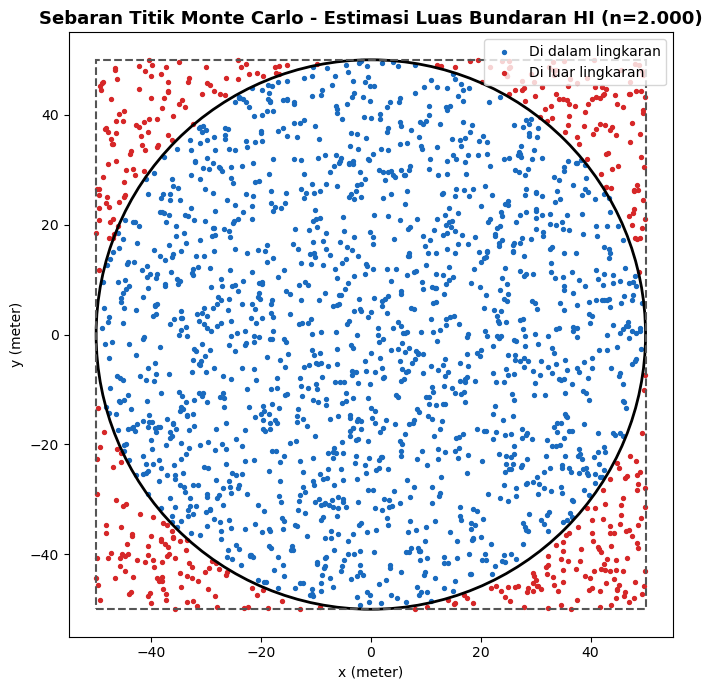

In [8]:
sim_visual = hitung_estimasi_luas(radius_bundaran_hi, n=2000, seed=42)

print(f"Jumlah titik total       : {sim_visual['n']}")
print(f"Jumlah titik di dalam    : {sim_visual['jumlah_dalam']}")
print(f"Estimasi luas lingkaran  : {sim_visual['luas_estimasi']:,.2f} m^2")
print(f"Luas analitik (pi*r^2)   : {luas_analitik:,.2f} m^2")
print(f"Estimasi pi              : {estimasi_pi(sim_visual['jumlah_dalam'], sim_visual['n']):.5f}")

plot_sebaran_titik(radius_bundaran_hi, sim_visual,
                    judul="Sebaran Titik Monte Carlo - Estimasi Luas Bundaran HI (n=2.000)")

### 4.3 Eksperimen Konvergensi untuk Berbagai Nilai $n$

Simulasi dijalankan untuk $n \in \{100,\ 1.000,\ 10.000,\ 100.000,\ 1.000.000\}$ untuk mengamati bagaimana estimasi luas, estimasi $\pi$, dan galat berubah seiring banyak titik total bertambah.

In [9]:
daftar_n = [100, 1_000, 10_000, 100_000, 1_000_000]
hasil_eksperimen = jalankan_eksperimen(daftar_n, radius_bundaran_hi, seed=42)

print(f"{'n':<12}{'Titik di Dalam':<18}{'Estimasi Luas (m^2)':<22}{'Galat Relatif (%)':<20}{'Estimasi pi'}")
print("-" * 90)
for h in hasil_eksperimen:
    print(f"{h['n']:<12,}{h['jumlah_dalam']:<18,}{h['luas_estimasi']:<22,.2f}"
          f"{h['galat_relatif_persen']:<20.4f}{h['pi_estimasi']:.5f}")

print(f"\nLuas analitik referensi (pi*r^2): {luas_analitik:,.2f} m^2")
print(f"Nilai pi referensi              : {np.pi:.5f}")

n           Titik di Dalam    Estimasi Luas (m^2)   Galat Relatif (%)   Estimasi pi
------------------------------------------------------------------------------------------
100         78                7,800.00              0.6873              3.12000
1,000       784               7,840.00              0.1780              3.13600
10,000      7,860             7,860.00              0.0766              3.14400
100,000     78,635            7,863.50              0.1212              3.14540
1,000,000   785,990           7,859.90              0.0754              3.14396

Luas analitik referensi (pi*r^2): 7,853.98 m^2
Nilai pi referensi              : 3.14159


### 4.4 Visualisasi Konvergensi Galat

Grafik berikut menunjukkan galat relatif estimasi luas terhadap $n$ pada skala log-log, dibandingkan dengan garis referensi teoritis $O(1/\sqrt{n})$ dari bagian 2.4.

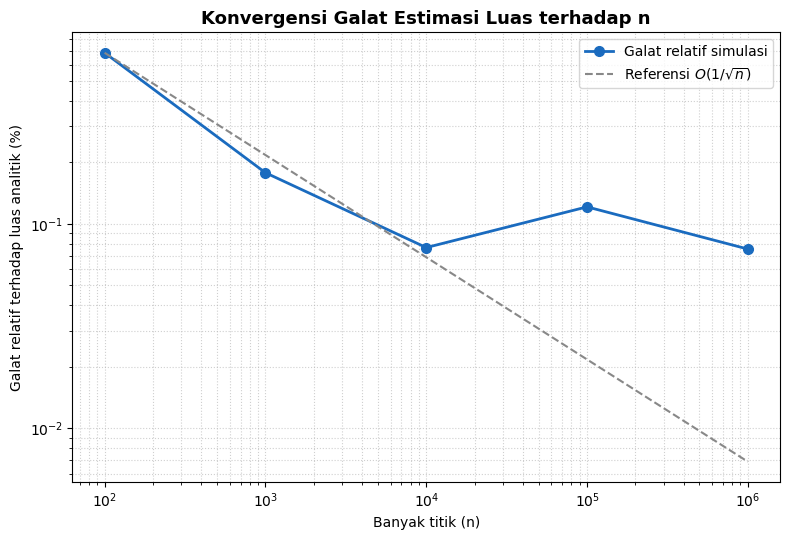

In [10]:
plot_konvergensi(hasil_eksperimen)

## 5. Kesimpulan

Studi kasus estimasi luas Bundaran HI berhasil mendemonstrasikan implementasi **Algoritma Monte Carlo** untuk persoalan estimasi luas, dengan poin-poin utama:

1. **Estimasi luas tanpa rumus tertutup** - dengan menyebar titik acak uniform pada persegi pembatas dan menghitung proporsi titik yang jatuh di dalam lingkaran, luas Bundaran HI (radius 50 m) dapat diestimasi mendekati nilai analitik $\pi r^2 \approx 7.853,98$ m² tanpa langsung memakai rumus tersebut dalam proses estimasinya.
2. **Akurasi membaik seiring $n$ bertambah** - pada $n=100$ galat relatif masih cukup besar (orde persen), namun pada $n=1.000.000$ galat relatif turun signifikan, sesuai dengan teori konvergensi $O(1/\sqrt{n})$ pada bagian 2.4: memperkecil galat 10 kali membutuhkan $n$ sekitar 100 kali lebih besar.
3. **Estimasi $\pi$ sebagai validasi independen** - karena rasio luas lingkaran terhadap persegi pembatas sama dengan $\pi/4$ terlepas dari nilai radius, estimasi $\hat{\pi} = 4 \times n_{\text{dalam}}/n$ ikut konvergen ke $3,14159...$, mengonfirmasi bahwa simulasi titik acak berjalan benar secara independen dari studi kasus radius spesifik yang dipakai.
4. **Sifat umum metode Monte Carlo** - meskipun pada studi kasus ini luas lingkaran sebenarnya bisa dihitung langsung dengan $\pi r^2$, prinsip yang sama (rasio titik acak di dalam vs di luar suatu daerah) dapat diterapkan untuk mengestimasi luas/volume bentuk-bentuk yang **tidak memiliki rumus analitik tertutup**, menjadikan Monte Carlo metode yang fleksibel meski konvergensinya relatif lambat dibanding metode numerik deterministik.
5. **Studi kasus Bundaran HI** menunjukkan bagaimana data publik (diameter ~100 m) dapat dipetakan menjadi parameter simulasi yang realistis untuk persoalan estimasi luas berbasis simulasi stokastik.